<a href="https://colab.research.google.com/github/jaehyeon0420/agent_tutorial/blob/master/rag_llm_answer_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 본 프로젝트는 질문 및 문서에 대한 LLM 답변을 평가합니다.
### 평가 방법 : LLM Judge, F1 Score
#### LLM Judge
- 응답 정확성 : 생성된 답변이 참조 답변과 비교하여 정확하고 완전한 정보를 제공하는지
- 컨텍스트 관련성 : 검색된 컨텍스트가 질문에 답하기 위해 관련성이 높은지
- 컨텍스트 충실성 : 생성된 답변이 주어진 컨텍스트에만 기반하는지
- 컨텍스트 충분성 : 검색된 컨텍스트가 질문에 완전히 답변하기에 충분한 정보를 포함하는지
#### F1 Score
- 정밀도(Precision) : TP/TP+FP = 검색된 문서 중 실제 정답이 얼마나 포함되었는지
- 재현율(Recall) : TP/TP+FN = 전체 정답 문서 중 시스템이 몇개나 찾아내었는지
- F1 Score : 2 * (Precision * Recall) / (Precision + Recall) = 정밀도와 재현율의 균형 점수

##### TP : 관련 있다고 예측했고, 실제로도 관련 있는 문서 개수
##### FP : 관련 있다고 예측했지만, 실제 관련 없는 문서
##### FN : 관련 없다고 예측했지만, 실제 관련 있는 문서

In [ ]:
!pip install -U openai chromadb pypdf tiktoken sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.4/512.4 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.

In [ ]:
import os
import json
from typing import List, Dict

# OpenAI API 관련
from openai import OpenAI

# 벡터 DB 관련
import chromadb
from chromadb.utils import embedding_functions

# PDF 로딩 관련
from pypdf import PdfReader

from sentence_transformers import SentenceTransformer
import torch

from google.colab import userdata

import pandas as pd

from tqdm import tqdm

#### PDF의 모든 텍스트를 하나의 문자열로 병합합니다.

In [ ]:
def load_pdf(file_path: str) -> str:
    reader = PdfReader(file_path)
    full_text = ""

    for page in reader.pages:
        # 페이지 텍스트 추출 (None 반환 대비)
        text = page.extract_text()
        if text:
            full_text += text + "\n"

    return full_text

pdf_text = load_pdf("대한민국 인공지능 행동계획.pdf")

#### 전체 문자열을 오버랩 기준으로 청킹하여 하나의 문자열 리스트를 생성합니다

In [ ]:
def chunk_text(text: str, chunk_size: int, chunk_overlap: int) -> List[str]:
    chunks = []

    # 시작 지점을 overlap만큼 이동하며 반복
    start = 0

    while start < len(text):
        # 종료 지점 계산
        end = start + chunk_size

        # 청킹
        chunk = text[start:end]
        chunks.append(chunk)

        # 다음 시작 지점 = 현재 종료 지점 - 오버랩
        start += (chunk_size - chunk_overlap)

        # 무한 루프 방지 (오버랩이 청크 사이즈보다 크거나 같을 경우)
        if chunk_size <= chunk_overlap:
            break

    return chunks

# 설정 값 예시
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 100

chunks = chunk_text(pdf_text, CHUNK_SIZE, CHUNK_OVERLAP)

In [ ]:
chunks[0]

'대한민국 인공지능 행동계획\n2026. 2. 25\n국가인공지능전략위원회\n- 2 -\n≪들어가며≫인공지능(AI)은 과학적 발견의 방식을 근본적으로 바꾸고, 산업의 구조를 다시 짜며, 인간의 사고와 소통, 학습의 영역까지 재정의하고 있습니다. 이 거대한 기술혁명은 세계 질서를 재편하고, 경제와 안보의 규칙을 새로 만듭니다. 우리는 반도체·이동 통신·자동차 산업에서 그랬던 것처럼, 인공지능(AI)을 새로운 도약의 발판으로 삼아 온 국민이 혜택을 얻는 인공지능 기본사회를 이루고자 합니다. 능동적이고 자주적인 대응으로 이 변화를 우리의 것으로 만드는 것은 우리의 과제입니다. 「대한민국 인공지능 행동계획」은 이러한 비전을 실현하기 위해 마련되었습니다. 이 계획은 단순한 기술정책이 아니라, 인공지능을 새로운 국가 성장엔진으로 삼아 산업을 혁신하고, 국민의 삶을 개선하며, 인류 공동의 번영에 기여하고자 합니다. 행동계획은 세가지 정책축과 12대 전략분야로 구성되었습니다:먼저 첫 번째 축은 인공지능 혁신 생태계 조성입니다.인공지능 경쟁의 승패는 일차적으로 인프라 역량의 보유 규모와 활용 역량에 좌우됩니다. 대한민국은 데이터, 컴퓨팅, 반도체, 전력 등 인공지능 개발･활용의 기초가 되는 국가 인프라인 AI고속도로를 구축하고, 이를 바탕으로 인공지능 생태계 전반의 혁신에 나서야 합니다. 또한 초거대 인공지능 모델과 핵심기술을 선점하고, 세계 최고 수준의 인공지능 인재를 양성하여 글로벌 인공지능 기술 개발의 맨 앞에 설 수 있어야 합니다. 이를 위해 역량 있는 인공지능 연구자와 기업들이 규제에 가로막히지 않고 혁신에 도전할 수 있도록 법·제도·행정 전반의 구조를 재편해야 합니다. 이러한 측면에서 첫 번째 축은 다섯 가지 전략분야로 구성됩니다: ① AI고속도로 구축, ② 차세대 인공지능 기술 선점, ③ 인공지능 핵심인재 확보, ④ 독자 범용 인공지능 모델 확보, ⑤ 인공지능 규제혁신입니다. 이 5가지 분야는 인공지능 강국의 토대를 마련하고, 다음 세대의 국가 경쟁력을 결정짓는 

In [ ]:
chunks[1]

' 핵심인재 확보, ④ 독자 범용 인공지능 모델 확보, ⑤ 인공지능 규제혁신입니다. 이 5가지 분야는 인공지능 강국의 토대를 마련하고, 다음 세대의 국가 경쟁력을 결정짓는 출발점이 될 것입니다.\n- 3 -\n두 번째 축은 범국가 인공지능 기반 대전환입니다.인공지능은 더 이상 특정 산업의 도구가 아니라, 국가 전체의 시스템을 바꾸는 원천입니다. 대한민국은 인공지능과 함께 산업, 공공, 지역, 국방, 문화 등 모든 국가영역의 혁신을 이룩해야 합니다. 인공지능은 제조·에너지·금융·바이오·의료 등 주력 산업의 효율성을 극대화하고, 행정과 복지, 교육 등 공공서비스의 품질을 획기적으로 개선할 수 있습니다. 또한 지역거점별 인공지능 허브 구축을 통해 수도권과 지방의 격차를 줄이고, 인공지능을 활용한 지능형 방위·안보 체계를 통해 첨단 국방 강국으로 도약해야 합니다. 아울러 우리가 가진 세계적인 장점인 K-문화와 K-콘텐츠산업에도 인공지능을 결합하여 창의성과 기술이 융합된 K-문화 르네상스를 열어가야 합니다. 이러한 측면에서 두 번째 축은 다섯 가지 전략분야로 구성됩니다: ⑥ 산업 인공지능 대전환, ⑦ 공공 인공지능 대전환, ⑧ 지역 인공지능 대전환, ⑨ 인공지능기반 문화강국, ⑩ 인공지능기반 국방강국 도약입니다. 이 5가지 전략 분야는 인공지능을 통해 국가 체계를 전면적으로 혁신하는 대한민국 인공지능 대전환 프로젝트입니다.마지막 축은 글로벌 인공지능 기본사회 기여입니다.인공지능 시대의 경쟁은 기술의 경쟁을 넘어 가치와 신뢰의 경쟁으로 진화하고 있습니다. 대한민국은 민주주의, 인권, 포용의 가치를 바탕으로 인공지능 기본사회를 실현하고, 국제사회가 신뢰할 수 있는 인공지능 거버넌스 모델을 제시해야 합니다. 인공지능이 국민 누구에게나 보편적 혜택으로 작동하고, 사회적 약자와 지역, 세대 간 격차를 줄이는 포용적 인공지능 복지 시스템을 구축하는 한편, 글로벌 인공지능 협력의 허브로서, 인공지능기술·데이터·인재 협력을 선도하고, 국제규범 논의와 공동 연구개발을 통해 세계 인공지

In [ ]:
client = OpenAI(api_key=userdata.get('OPEN_AI_KEY'))

def generate_qa_dataset(chunks: List[str], num_samples: int = 50):
    """
    Chunks 기반으로 질문(Q)과 모범 답안(A) 생성

    Args:
        chunks: 문서 청크 리스트 (문자열)
        num_samples: 생성할 Q&A 쌍의 개수

    Returns:
        - questions: 생성된 질문 리스트
        - labels: 생성된 모범 답안 리스트
        - contexts: 각 질문의 참조 청크 리스트

    Example:
        >>> questions, labels, contexts = generate_qa_dataset(chunks)
        >>> len(questions)  # 50
    """

    questions = []
    labels = []
    contexts = []

    # 처리할 청크 수 제한
    chunks_to_process = chunks[:num_samples]
    total = len(chunks_to_process)

    print(f"Q&A 데이터셋 생성 시작")
    print(f"   처리 대상: {total}개 청크")
    print("=" * 60)

    for idx, chunk in enumerate(chunks_to_process, 1):
        try:
            # GPT-4o에 요청
            response = client.chat.completions.create(
                model="gpt-4o",
                messages=[
                    {
                        "role": "system",
                        "content": """당신은 교육용 평가 데이터셋을 생성하는 전문가입니다.

                        주어진 텍스트(context)에 기반하여 하나의 간단한 질문과 그에 해당하는 답변을 생성하세요.

                        요구사항:
                        1. 질문은 주어진 텍스트의 핵심 내용을 다루어야 합니다.
                        2. 답변은 텍스트에 직접 나타난 정보만을 기반으로 모든 내용에 대한 설명이 포함되도록 풍부하게 작성하세요.
                        3. 질문은 너무 지엽적이고 너무 긴 질문은 지양합니다.
                        4. 질문과 답변을 생성할 때, 텍스트가 질문과 답변에 부합하다는 근거를 작성하세요.

                        응답 형식 (JSON):
                        {
                            "question": "생성된 질문",
                            "reason" : "생성 근거",
                            "answer": "생성된 답변"
                        }"""
                    },
                    {
                        "role": "user",
                        "content": f"""다음 텍스트에 기반하여 1개의 질문-답변 쌍을 생성하세요:

                                      텍스트:
                                      -----
                                      {chunk}
                                      -----

                                      JSON 형식으로 응답하세요."""
                    }
                ],
                temperature=0.5,
                max_tokens=1000
            )

            # 응답 파싱
            response_text = response.choices[0].message.content

            # JSON 추출 (마크다운 코드블록 처리)
            if "```json" in response_text:
                response_text = response_text.split("```json")[1].split("```")[0].strip()
            elif "```" in response_text:
                response_text = response_text.split("```")[1].split("```")[0].strip()

            qa_pair = json.loads(response_text)

            question = qa_pair.get("question", "").strip()
            answer = qa_pair.get("answer", "").strip()

            # 유효성 검증
            if question and answer and len(question) > 5 and len(answer) > 5:
                questions.append(question)
                labels.append(answer)
                contexts.append(chunk)

                # 진행 상황 표시
                if idx % 5 == 0:
                    print(f"✓ [{idx}/{total}] Q&A 생성 완료")
            else:
                print(f"⚠️  [{idx}/{total}] 유효하지 않은 Q&A 건너뜀")


        except json.JSONDecodeError as e:
            print(f"[{idx}/{total}] JSON 파싱 실패: {str(e)}")
            continue
        except Exception as e:
            print(f"[{idx}/{total}] API 에러: {str(e)}")
            import time
            time.sleep(2)
            continue

    print(f"Q&A 데이터셋 생성 완료!")

    return questions, labels, contexts

In [ ]:
# 테스트를 위해 100개 청크만 진행
questions, labels, contexts = generate_qa_dataset(chunks, 100)

Q&A 데이터셋 생성 시작
   처리 대상: 100개 청크
✓ [5/100] Q&A 생성 완료
✓ [10/100] Q&A 생성 완료
✓ [15/100] Q&A 생성 완료
✓ [20/100] Q&A 생성 완료
✓ [25/100] Q&A 생성 완료
✓ [30/100] Q&A 생성 완료
✓ [35/100] Q&A 생성 완료
✓ [40/100] Q&A 생성 완료
✓ [45/100] Q&A 생성 완료
✓ [50/100] Q&A 생성 완료
✓ [55/100] Q&A 생성 완료
✓ [60/100] Q&A 생성 완료
✓ [65/100] Q&A 생성 완료
✓ [70/100] Q&A 생성 완료
✓ [75/100] Q&A 생성 완료
✓ [80/100] Q&A 생성 완료
✓ [85/100] Q&A 생성 완료
✓ [90/100] Q&A 생성 완료
✓ [95/100] Q&A 생성 완료
✓ [100/100] Q&A 생성 완료
Q&A 데이터셋 생성 완료!


In [ ]:
contexts[0]

'대한민국 인공지능 행동계획\n2026. 2. 25\n국가인공지능전략위원회\n- 2 -\n≪들어가며≫인공지능(AI)은 과학적 발견의 방식을 근본적으로 바꾸고, 산업의 구조를 다시 짜며, 인간의 사고와 소통, 학습의 영역까지 재정의하고 있습니다. 이 거대한 기술혁명은 세계 질서를 재편하고, 경제와 안보의 규칙을 새로 만듭니다. 우리는 반도체·이동 통신·자동차 산업에서 그랬던 것처럼, 인공지능(AI)을 새로운 도약의 발판으로 삼아 온 국민이 혜택을 얻는 인공지능 기본사회를 이루고자 합니다. 능동적이고 자주적인 대응으로 이 변화를 우리의 것으로 만드는 것은 우리의 과제입니다. 「대한민국 인공지능 행동계획」은 이러한 비전을 실현하기 위해 마련되었습니다. 이 계획은 단순한 기술정책이 아니라, 인공지능을 새로운 국가 성장엔진으로 삼아 산업을 혁신하고, 국민의 삶을 개선하며, 인류 공동의 번영에 기여하고자 합니다. 행동계획은 세가지 정책축과 12대 전략분야로 구성되었습니다:먼저 첫 번째 축은 인공지능 혁신 생태계 조성입니다.인공지능 경쟁의 승패는 일차적으로 인프라 역량의 보유 규모와 활용 역량에 좌우됩니다. 대한민국은 데이터, 컴퓨팅, 반도체, 전력 등 인공지능 개발･활용의 기초가 되는 국가 인프라인 AI고속도로를 구축하고, 이를 바탕으로 인공지능 생태계 전반의 혁신에 나서야 합니다. 또한 초거대 인공지능 모델과 핵심기술을 선점하고, 세계 최고 수준의 인공지능 인재를 양성하여 글로벌 인공지능 기술 개발의 맨 앞에 설 수 있어야 합니다. 이를 위해 역량 있는 인공지능 연구자와 기업들이 규제에 가로막히지 않고 혁신에 도전할 수 있도록 법·제도·행정 전반의 구조를 재편해야 합니다. 이러한 측면에서 첫 번째 축은 다섯 가지 전략분야로 구성됩니다: ① AI고속도로 구축, ② 차세대 인공지능 기술 선점, ③ 인공지능 핵심인재 확보, ④ 독자 범용 인공지능 모델 확보, ⑤ 인공지능 규제혁신입니다. 이 5가지 분야는 인공지능 강국의 토대를 마련하고, 다음 세대의 국가 경쟁력을 결정짓는 

In [ ]:
questions[0]

'대한민국 인공지능 행동계획의 첫 번째 정책축은 무엇이며, 이를 위해 어떤 전략분야들이 포함되어 있습니까?'

In [ ]:
labels[0]

'대한민국 인공지능 행동계획의 첫 번째 정책축은 인공지능 혁신 생태계 조성입니다. 이를 위해 다섯 가지 전략분야가 포함되어 있는데, 이는 AI고속도로 구축, 차세대 인공지능 기술 선점, 인공지능 핵심인재 확보, 독자 범용 인공지능 모델 확보, 인공지능 규제혁신입니다. 이 분야들은 인공지능 강국의 토대를 마련하고, 국가 경쟁력을 결정짓는 출발점이 됩니다.'

### 평가 대상 LLM 답변 생성

In [ ]:
def generate_predictions(questions: List[str], contexts: List[str]) :
    """
    생성된 질문들에 대해 GPT-4o 기반 답변 생성

    Args:
        questions: 질문 리스트
        contexts: 각 질문의 참조 컨텍스트(청크) 리스트

    Returns:
        predictions: GPT-4o가 생성한 답변 리스트

    Example:
        >>> predictions = generate_predictions(questions, contexts)
        >>> len(predictions)  # 50
    """

    predictions = []
    total = len(questions)

    print(f"GPT-4o 답변 생성 시작")
    print(f"   처리 대상: {total}개 질문")
    print("=" * 60)

    for idx, (question, context) in enumerate(zip(questions, contexts), 1):
        try:
            # GPT-4o에 요청
            response = client.chat.completions.create(
                model="gpt-4o",
                messages=[
                    {
                        "role": "system",
                        "content": """당신은 주어진 컨텍스트(참조 정보)를 기반으로 질문에 답하는 AI 어시스턴트입니다.

                                    요구사항:
                                    1. 제공된 컨텍스트의 정보만 사용하여 답변하세요.
                                    2. 컨텍스트에 없는 추가 정보는 포함하지 마세요.
                                    3. 답변만 제공하세요 (추가 설명, 전치사, 추가 제안 제외)."""
                    },
                    {
                        "role": "user",
                        "content": f"""컨텍스트:
                                        -----
                                        {context}
                                        -----

                                        질문: {question}

                                        위 컨텍스트를 기반으로 위 질문에 답해주세요.
                                        추가 제안이나, 전치사를 제외하고 답변만 제공하세요"""
                    }
                ],
                temperature=0.3,  # 더 일관성 있는 답변
                max_tokens=1000,
            )

            prediction = response.choices[0].message.content.strip()
            predictions.append(prediction)

            # 진행 상황 표시
            if idx % 5 == 0:
                print(f"✓ [{idx}/{total}] 답변 생성 완료")


        except Exception as e:
            print(f"[{idx}/{total}] API 에러: {str(e)}")
            predictions.append("")  # 빈 응답 추가
            import time
            time.sleep(2)
            continue


    return predictions

In [ ]:
predeictions = generate_predictions(questions, contexts)

GPT-4o 답변 생성 시작
   처리 대상: 100개 질문
✓ [5/100] 답변 생성 완료
✓ [10/100] 답변 생성 완료
✓ [15/100] 답변 생성 완료
✓ [20/100] 답변 생성 완료
✓ [25/100] 답변 생성 완료
✓ [30/100] 답변 생성 완료
✓ [35/100] 답변 생성 완료
✓ [40/100] 답변 생성 완료
✓ [45/100] 답변 생성 완료
✓ [50/100] 답변 생성 완료
✓ [55/100] 답변 생성 완료
✓ [60/100] 답변 생성 완료
✓ [65/100] 답변 생성 완료
✓ [70/100] 답변 생성 완료
✓ [75/100] 답변 생성 완료
✓ [80/100] 답변 생성 완료
✓ [85/100] 답변 생성 완료
✓ [90/100] 답변 생성 완료
✓ [95/100] 답변 생성 완료
✓ [100/100] 답변 생성 완료


### LLM Judge 답변 평가

In [ ]:
import time

def evaluate_rag_with_llm(questions, contexts, predictions, labels):
    """
    LLM 평가 메트릭으로 RAG 시스템 평가

    Args:
        questions: 질문 리스트
        contexts: 검색 결과 리스트
        predictions: 예측 리스트
        labels: 레이블 리스트

    Returns:
        평가 결과가 포함된 데이터프레임
    """

    # 결과를 저장할 리스트
    results = []

    # 평가 프롬프트
    prompt_template = """
당신은 RAG(Retrieval-Augmented Generation) 시스템 평가 전문가입니다. 아래 정보를 바탕으로 생성된 답변의 품질을 철저히 평가해주세요.

질문: {question}

검색된 컨텍스트:
{context}

생성된 답변:
{prediction}

참조 답변(정답):
{label}

다음 4가지 평가 기준으로 1-5점 척도로 점수를 매겨주세요:

1. 응답 정확성 (Answer Correctness) [1-5]:
   * 생성된 답변이 참조 답변과 비교하여 정확하고 완전한 정보를 제공하는지 평가
   * 1점: 완전히 잘못된 정보
   * 2점: 부분적으로 관련된 정보를 담고 있으나 대부분 부정확함
   * 3점: 정확한 정보와 부정확한 정보가 혼재되어 있음
   * 4점: 대부분 정확하지만 일부 정보가 누락되거나 미미한 오류가 있음
   * 5점: 참조 답변과 비교했을 때 완전히 정확하고 포괄적인 정보를 제공함

2. 컨텍스트 관련성 (Context Relevance) [1-5]:
   * 검색된 컨텍스트가 질문에 대답하기 위해 관련성이 높은지 평가
   * 1점: 컨텍스트가 질문과 전혀 관련이 없음
   * 2점: 컨텍스트가 질문과 간접적으로만 관련됨
   * 3점: 컨텍스트 중 일부만 질문과 직접적으로 관련됨
   * 4점: 대부분의 컨텍스트가 질문과 직접적으로 관련됨
   * 5점: 모든 컨텍스트가 질문에 완벽하게 관련되어 있고 불필요한 정보가 없음

3. 컨텍스트 충실성 (Context Faithfulness) [1-5]:
   * 생성된 답변이 주어진 컨텍스트에만 기반하는지, 아니면 없는 정보를 추가했는지 평가
   * 1점: 답변이 컨텍스트에 없는 정보로만 구성됨 (심각한 환각)
   * 2점: 답변이 주로 컨텍스트에 없는 정보로 구성됨
   * 3점: 답변이 컨텍스트 정보와 없는 정보가 혼합되어 있음
   * 4점: 답변이 주로 컨텍스트에 기반하지만 약간의 추가 정보가 있음
   * 5점: 답변이 전적으로 컨텍스트에 있는 정보만을 사용함

4. 컨텍스트 충분성 (Context Recall) [1-5]:
   * 검색된 컨텍스트가 질문에 완전히 답변하기에 충분한 정보를 포함하는지 평가
   * 1점: 컨텍스트가 답변에 필요한 정보를 전혀 포함하지 않음
   * 2점: 컨텍스트가 필요한 정보의 일부만 포함함
   * 3점: 컨텍스트가 필요한 정보의 약 절반을 포함함
   * 4점: 컨텍스트가 필요한 정보의 대부분을 포함하지만 일부 누락됨
   * 5점: 컨텍스트가 질문에 완전히 답변하기 위한 모든 필요한 정보를 포함함

반드시 다음 JSON 형식으로만 응답하세요. 마크다운은 사용하지 않습니다.:
{
  "answer_correctness": 정수로 된 점수(1-5),
  "context_relevance": 정수로 된 점수(1-5),
  "context_faithfulness": 정수로 된 점수(1-5),
  "context_recall": 점수(1-5),
  "analysis": "종합적인 분석 의견"
}

다른 형식의 응답은 하지 마세요. 오직 마크다운이 아닌 JSON만 반환하세요.
"""

    # 각 항목에 대해 평가 수행
    for i in tqdm(range(len(questions)), total=len(questions), desc="RAG 평가 진행 중"):
        try:
            # 프롬프트 생성 - format 대신 replace 사용
            prompt = prompt_template
            prompt = prompt.replace("{question}", str(questions[i]) if questions[i] is not None else "")
            prompt = prompt.replace("{context}", str(contexts[i]) if contexts[i] is not None else "")
            prompt = prompt.replace("{prediction}", str(predictions[i]) if predictions[i] is not None else "")
            prompt = prompt.replace("{label}", str(labels[i]) if labels[i] is not None else "")

            # GPT-4 API 호출
            response = client.chat.completions.create(
                model="gpt-4o",
                messages=[
                    {"role": "system", "content": "당신은 RAG 평가 도구입니다. 반드시 유효한 JSON 형식으로만 응답하세요."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0,
                response_format={"type": "json_object"}
            )

            # 결과 파싱
            result = json.loads(response.choices[0].message.content)

            # 개별 메트릭 점수 추출
            answer_correctness = result['answer_correctness']
            context_relevance = result['context_relevance']
            context_faithfulness = result['context_faithfulness']
            context_recall = result['context_recall']

            # 총점 직접 계산 (개별 메트릭의 합)
            total_score = answer_correctness + context_relevance + context_faithfulness + context_recall

            # 원본 데이터와 평가 결과 결합
            row_result = {
                'id': i,
                'question': questions[i],
                'answer_correctness': answer_correctness,
                'context_relevance': context_relevance,
                'context_faithfulness': context_faithfulness,
                'context_recall': context_recall,
                'total_score': total_score,
                'analysis': result['analysis']
            }

            results.append(row_result)

            time.sleep(1)

        except Exception as e:
            print(f"항목 {i} 평가 중 오류 발생: {e}")
            results.append({
                'id': i,
                'question': questions[i],
                'error': str(e)
            })

    # 결과 데이터프레임 생성
    results_df = pd.DataFrame(results)

    # 요약 통계 계산
    if 'total_score' in results_df.columns:
        metrics_summary = {
            '평균 총점': results_df['total_score'].mean(),
            '응답 정확성 평균': results_df['answer_correctness'].mean(),
            '컨텍스트 관련성 평균': results_df['context_relevance'].mean(),
            '컨텍스트 충실성 평균': results_df['context_faithfulness'].mean(),
            '컨텍스트 충분성 평균': results_df['context_recall'].mean()
        }
        print("\n===== 평가 요약 =====")
        for metric, value in metrics_summary.items():
            print(f"{metric}: {value:.2f}")

    return results_df, metrics_summary if 'total_score' in results_df.columns else results_df

In [ ]:
results_df, metrics_summary = evaluate_rag_with_llm(questions, contexts, predeictions, labels)

RAG 평가 진행 중: 100%|██████████| 100/100 [05:20<00:00,  3.21s/it]


===== 평가 요약 =====
평균 총점: 18.85
응답 정확성 평균: 4.02
컨텍스트 관련성 평균: 4.98
컨텍스트 충실성 평균: 4.88
컨텍스트 충분성 평균: 4.97


### [상세 분석 보고서] ###
answer_correctness      4.02
context_relevance       4.98
context_faithfulness    4.88
context_recall          4.97
dtype: float64

### [시스템 성능 진단] ###


/tmp/ipykernel_452/2040634208.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=summary.index, y=summary.values, palette='viridis')


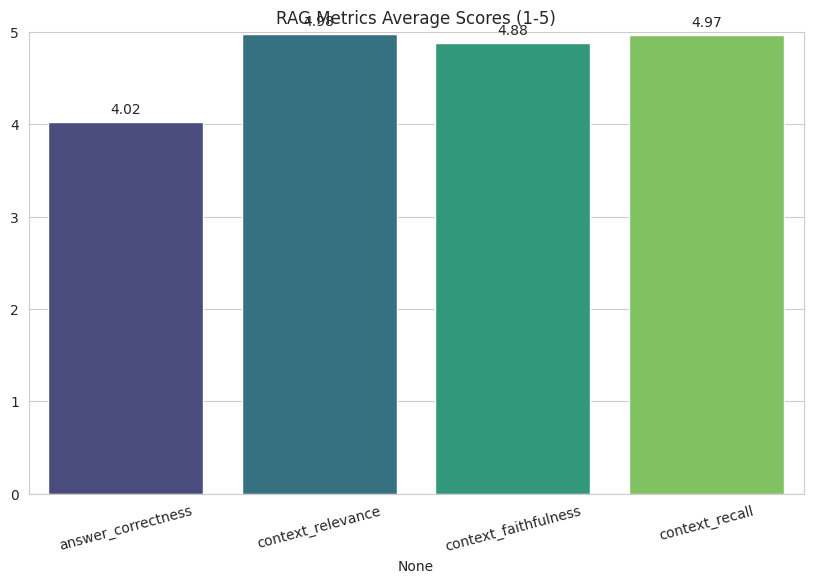


### [집중 케어 필요 케이스 - 총점 최하위 3개] ###

[ID 2] 질문: 대한민국의 인공지능 행동계획의 주요 목표는 무엇인가요?
분석 의견: 생성된 답변은 '인공지능 3대 강국 도약'이라는 부분적인 정보를 제공하지만, 이는 질문에 대한 충분한 답변이 아닙니다. 참조 답변에서는 정책 목표와 권고사항, 국민의 삶 향상 및 인류 공동 번영 기여 등의 목표를 포함하고 있습니다. 검색된 컨텍스트는 질문과 관련성이 높고, 대부분의 필요한 정보를 포함하고 있지만, 생성된 답변은 컨텍스트의 정보를 충분히 활용하지 못하고 있습니다. 따라서 생성된 답변은 컨텍스트에 기반하지 않은 정보로 구성되어 있으며, 정확성과 충실성에서 낮은 점수를 받았습니다.

[ID 29] 질문: AI 융합 인력 양성을 위해 대학이 어떤 역할을 해야 한다고 제안하고 있나요?
분석 의견: 생성된 답변은 '학습 촉진자'와 '혁신 플랫폼'이라는 키워드를 제공하지만, 참조 답변에 비해 구체적인 설명이 부족하여 정확성이 떨어집니다. 컨텍스트는 질문과 관련성이 높고, 필요한 정보를 충분히 포함하고 있어 컨텍스트 관련성과 충분성 점수는 높습니다. 생성된 답변은 주어진 컨텍스트에 기반하고 있어 충실성 점수도 높지만, 정보의 구체성이 부족하여 정확성 점수가 낮습니다.

[ID 95] 질문: AI 보조교사 도입 및 교육행정 혁신에서 AI 기술이 교사에게 어떤 역할을 수행할 것으로 기대되나요?
분석 의견: 생성된 답변은 교사의 업무 지원에 대한 일부 정보를 제공하지만, AI 기술이 교사의 업무를 지원하여 교육의 질을 높이는 데 기여할 것이라는 중요한 부분이 누락되었습니다. 컨텍스트는 질문에 매우 관련성이 높고 충분한 정보를 제공하지만, 생성된 답변은 컨텍스트의 정보를 충분히 활용하지 못했습니다. 또한, 생성된 답변은 컨텍스트에 기반한 정보와 그렇지 않은 정보가 혼재되어 있어 충실성이 떨어집니다.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def analyze_rag_results(results_df):
    """
    평가 결과를 분석하고 시각화하는 함수
    """
    # 1. 기초 통계 확인
    print("### [상세 분석 보고서] ###")
    metrics = ['answer_correctness', 'context_relevance', 'context_faithfulness', 'context_recall']
    summary = results_df[metrics].mean()
    print(summary)

    # 2. 시스템 진단 로직
    print("\n### [시스템 성능 진단] ###")
    if summary['context_relevance'] < 3.5:
        print("-> [경고] 리트리버(검색)가 질문과 무관한 내용을 가져오고 있습니다. 임베딩 모델을 점검하세요.")
    if summary['context_faithfulness'] < 3.5:
        print("-> [경고] 모델이 환각(Hallucination) 증세를 보입니다. 출처 기반 생성 지시를 강화하세요.")
    if summary['context_recall'] < 3.5:
        print("-> [경고] 검색 결과에 정답을 위한 정보가 부족합니다. 청크 크기나 검색 개수(k)를 늘리세요.")
    if summary['answer_correctness'] < 3.5:
        print("-> [경고] 최종 답변 품질이 낮습니다. 프롬프트 엔지니어링이 필요합니다.")

    # 3. 시각화 (레이더 차트 또는 막대 그래프)
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # 평균 점수 시각화
    ax = sns.barplot(x=summary.index, y=summary.values, palette='viridis')
    ax.set_title('RAG Metrics Average Scores (1-5)')
    ax.set_ylim(0, 5)

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points')

    plt.xticks(rotation=15)
    plt.show()

    # 4. 가장 점수가 낮은(취약한) 케이스 TOP 3 추출
    print("\n### [집중 케어 필요 케이스 - 총점 최하위 3개] ###")
    worst_cases = results_df.nsmallest(3, 'total_score')
    for i, row in worst_cases.iterrows():
        print(f"\n[ID {row['id']}] 질문: {row['question']}")
        print(f"분석 의견: {row['analysis']}")


analyze_rag_results(results_df)

### 정량 평가 (F1 Score)
#### F1 Score는 모델이 정답을 얼마나 놓치지 않았는지(재현율)와 맞다고 답한 것 중 실제 정답이 얼마나 있는지(정밀도)를 모두 고려합니다.
#### 다만, 답변에 할루시네이션이 포함된 경우는 평가에 반영되지 않으므로, 상단의 LLM Judge와 종합적인 판단이 필요합니다.

In [ ]:
import json
from typing import List, Dict, Tuple
from openai import OpenAI

def generate_question_and_answer(chunks: List[str]) -> Dict[str, str]:
    """
    다수의 청크를 바탕으로 하나의 질문과 그에 대한 모범 답변을 생성합니다.
    답변에는 반드시 [[refN]] 형태의 인용이 포함됩니다.
    """

    # 청크에 번호를 매겨 프롬프트에 주입할 텍스트 구성
    context_text = "\n\n".join([f"[문서 {i+1}]\n{chunk}" for i, chunk in enumerate(chunks)])

    system_prompt = """당신은 훌륭한 독해 및 RAG(검색 증강 생성) 평가 데이터셋 구축 전문가입니다.
    제공된 5개의 문서를 읽고, 이 문서들 중 1~5개의 내용을 조합해야만 대답할 수 있는 '질문'과 그에 대한 '모범 답변'을 만드세요.

    [지시사항]
    1. 답변 작성 시, 특정 문서의 내용을 참조한 문장 끝에는 반드시 [[ref1]], [[ref3]]과 같이 참조한 문서 번호를 표기하세요.
    2. 외부 지식은 절대 사용하지 말고 오직 제공된 문서 내용에만 기반해야 합니다.
    3. 출력은 반드시 아래 JSON 형식을 엄격히 준수하세요. 마크다운 코드 블록이나 다른 설명은 덧붙이지 마세요.
    {
      "question": "생성된 질문",
      "answer": "생성된 모범 답변 (인용 마커 포함)"
    }"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"다음 문서를 바탕으로 질문과 답변 쌍을 JSON으로 생성해주세요:\n\n{context_text}"}
            ],
            temperature=0, # 사실적이고 일관된 결과를 위해 0으로 설정
            response_format={"type": "json_object"} # 파싱 안정성을 위해 JSON 모드 강제
        )

        result_json = json.loads(response.choices[0].message.content)
        return result_json

    except Exception as e:
        print(f"QA 생성 중 에러 발생: {e}")
        return {"question": "", "answer": ""}

In [ ]:
# 테스트
result = generate_question_and_answer(chunks[:5])

In [ ]:
result['question']

'대한민국 인공지능 행동계획의 주요 정책축과 전략분야는 무엇인가요?'

In [ ]:
result['answer']

"대한민국 인공지능 행동계획은 세 가지 주요 정책축으로 구성되어 있습니다. 첫 번째 축은 '인공지능 혁신 생태계 조성'으로, AI고속도로 구축, 차세대 인공지능 기술 선점, 인공지능 핵심인재 확보, 독자 범용 인공지능 모델 확보, 인공지능 규제혁신의 다섯 가지 전략분야로 구성됩니다[[ref1]]. 두 번째 축은 '범국가 인공지능 기반 대전환'으로, 산업 인공지능 대전환, 공공 인공지능 대전환, 지역 인공지능 대전환, 인공지능기반 문화강국, 인공지능기반 국방강국 도약의 다섯 가지 전략분야로 구성됩니다[[ref2]]. 마지막으로 세 번째 축은 '글로벌 인공지능 기본사회 기여'로, 인공지능기본사회 실현과 글로벌 인공지능 이니셔티브 강화의 두 가지 전략분야로 구성됩니다[[ref3]]."

In [ ]:
def generate_target_answer(chunks: List[str], question: str) -> str:
    """
    5개의 청크와 질문을 바탕으로 LLM이 답변을 생성합니다.
    답변에는 반드시 [[refN]] 형태의 인용이 포함됩니다.
    """

    # 청크에 번호를 매겨 프롬프트에 주입할 텍스트 구성
    context_text = "\n\n".join([f"[문서 {i+1}]\n{chunk}" for i, chunk in enumerate(chunks)])

    system_prompt = """당신은 주어진 문서에만 기반하여 사용자의 질문에 답변하는 AI 어시스턴트입니다.

                    [지시사항]
                    1. 오직 제공된 문서의 정보만을 사용하여 답변하세요. 문서에 없는 내용은 절대 지어내지 마세요.
                    2. 답변의 각 문장이나 주장의 끝에는 그 출처가 되는 문서의 번호를 [[ref1]], [[ref3]]과 같은 형식으로 반드시 표기하세요.
                    3. 여러 문서를 참조했다면 [[ref1, ref4]] 또는 [[ref1]], [[ref4]] 형식으로 표기하세요.
                    4. 주어진 문서만으로 답변할 수 없는 질문이라면 "제공된 문서에서 답변을 찾을 수 없습니다."라고 답변하세요."""

    user_prompt = f"""[참고 문서]
                    {context_text}

                    [질문]
                    {question}"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0 # 사실 기반 답변을 강제하기 위해 0으로 설정
        )

        return response.choices[0].message.content.strip()

    except Exception as e:
        print(f"답변 생성 중 에러 발생: {e}")
        return ""

In [ ]:
import re

def extract_ref_numbers(text: str) -> List[int]:
    """
    텍스트에서 [[ref숫자]] 패턴의 숫자들을 추출하여 중복 없이 정렬된 리스트로 반환합니다.

    Args:
        text (str): 분석할 텍스트

    Returns:
        List[int]: 추출된 숫자들의 정렬된 리스트

    Example:
        >>> text = "이것은 [[ref1]]과 [[ref2]], [[ref1]]입니다."
        >>> extract_ref_numbers(text)
        [1, 2]
    """
    # [[ref숫자]] 패턴을 찾는 정규표현식
    pattern = r'\[\[ref(\d+)\]\]'

    # 모든 매치를 찾아서 숫자만 추출
    numbers = [int(match.group(1)) for match in re.finditer(pattern, text)]

    # 중복 제거하고 정렬하여 반환
    return sorted(list(set(numbers)))

In [ ]:
import itertools

def batch_iterable(iterable, size):
    """리스트를 지정된 사이즈만큼 잘라서 반환하는 제너레이터"""
    it = iter(iterable)
    while True:
        chunk = list(itertools.islice(it, size))
        if not chunk:
            break
        yield chunk

def run_evaluation_pipeline(full_chunks: List[str]):
    """메인 실행 루프 (자투리 청크 처리 포함)"""
    evaluation_dataset = []

    # 5개씩 묶기 (itertools.islice는 남은 개수가 5개 미만이어도 있는 만큼 다 가져옴)
    chunks_batches = list(batch_iterable(full_chunks, 5))

    print(f"총 {len(chunks_batches)}개의 배치를 처리합니다.")

    for i, batch in enumerate(tqdm(chunks_batches, desc="진행 중")):
        # 이제 len(batch)가 1~5 사이면 무조건 실행됨
        gt_data = generate_question_and_answer(batch)
        question = gt_data.get("question")
        reference_answer = gt_data.get("answer")

        if not question:
            continue

        predicted_answer = generate_target_answer(batch, question)

        # 인용 문서 번호 리스트 추출
        reference_ref_list = extract_ref_numbers(reference_answer)
        predicted_ref_list = extract_ref_numbers(predicted_answer)

        evaluation_dataset.append({
            "question": question,
            "reference_answer": reference_answer,
            "reference_ref_list": reference_ref_list,
            "predicted_answer": predicted_answer,
            "predicted_ref_list": predicted_ref_list,
        })

    return evaluation_dataset

In [ ]:
# 동일하게 100개 청크만 테스트
evaluation_dataset = run_evaluation_pipeline(chunks[:100])

총 20개의 배치를 처리합니다.


진행 중: 100%|██████████| 20/20 [03:36<00:00, 10.84s/it]


In [ ]:
len(evaluation_dataset)

20

In [ ]:
evaluation_dataset[0]['question']

'대한민국 인공지능 행동계획의 주요 정책축과 전략분야는 무엇인가요?'

In [ ]:
evaluation_dataset[0]['reference_answer']

"대한민국 인공지능 행동계획은 세 가지 주요 정책축으로 구성되어 있습니다. 첫 번째 축은 '인공지능 혁신 생태계 조성'으로, AI고속도로 구축, 차세대 인공지능 기술 선점, 인공지능 핵심인재 확보, 독자 범용 인공지능 모델 확보, 인공지능 규제혁신의 다섯 가지 전략분야로 구성됩니다[[ref1]]. 두 번째 축은 '범국가 인공지능 기반 대전환'으로, 산업 인공지능 대전환, 공공 인공지능 대전환, 지역 인공지능 대전환, 인공지능기반 문화강국, 인공지능기반 국방강국 도약의 다섯 가지 전략분야로 구성됩니다[[ref2]]. 마지막으로 세 번째 축은 '글로벌 인공지능 기본사회 기여'로, 인공지능기본사회 실현과 글로벌 인공지능 이니셔티브 강화의 두 가지 전략분야로 구성됩니다[[ref3]]."

In [ ]:
evaluation_dataset[0]['reference_ref_list']

[1, 2, 3]

In [ ]:
evaluation_dataset[0]['predicted_answer']

'대한민국 인공지능 행동계획은 세 가지 주요 정책축과 12대 전략분야로 구성되어 있습니다.\n\n1. **AI 혁신 생태계 조성**: \n   - AI고속도로 구축\n   - 차세대 인공지능 기술 선점\n   - 인공지능 핵심인재 확보\n   - 독자 범용 인공지능 모델 확보\n   - 인공지능 규제혁신 [[ref1]].\n\n2. **범국가 인공지능 기반 대전환**:\n   - 산업 인공지능 대전환\n   - 공공 인공지능 대전환\n   - 지역 인공지능 대전환\n   - 인공지능기반 문화강국\n   - 인공지능기반 국방강국 도약 [[ref2]].\n\n3. **글로벌 인공지능 기본사회 기여**:\n   - 인공지능기본사회 실현\n   - 글로벌 인공지능 이니셔티브 강화 [[ref3]].'

In [ ]:
evaluation_dataset[0]['predicted_ref_list']

[1, 2, 3]

In [ ]:
def calculate_f1_score(labels, predictions):
    """
    F1 score 계산 (multilabel 케이스) - 이중 리스트 입력 지원

    Args:
        labels: 샘플별 실제 레이블이 담긴 리스트 또는 이중 리스트
        predictions: 샘플별 예측 레이블이 담긴 리스트 또는 이중 리스트

    Returns:
        F1 점수
    """
    # 입력 형식 확인
    is_nested_list = isinstance(labels, list) and len(labels) > 0 and isinstance(labels[0], list)

    # 이중 리스트가 아니면 이중 리스트로 변환
    if not is_nested_list:
        labels = [labels]
        predictions = [predictions]

    # 길이 확인
    if len(labels) != len(predictions):
        raise ValueError("라벨과 예측의 길이가 일치하지 않습니다.")

    # 전체 통계 초기화
    total_true_positives = 0
    total_false_positives = 0
    total_false_negatives = 0

    # 각 샘플에 대해 계산
    for sample_labels, sample_preds in zip(labels, predictions):
        # 빈 리스트는 빈 집합으로 변환
        if not sample_labels:
            sample_labels = set()
        else:
            sample_labels = set(sample_labels)

        if not sample_preds:
            sample_preds = set()
        else:
            sample_preds = set(sample_preds)

        # 통계 계산
        true_positives = len(sample_labels.intersection(sample_preds))
        false_positives = len(sample_preds - sample_labels)
        false_negatives = len(sample_labels - sample_preds)

        # 전체 통계에 추가
        total_true_positives += true_positives
        total_false_positives += false_positives
        total_false_negatives += false_negatives

    # 특수 케이스: 둘 다 빈 리스트인 경우는 F1 = 1.0으로 처리
    if sum(bool(l) for l in labels) == 0 and sum(bool(p) for p in predictions) == 0:
        return 1.0

    # 정밀도와 재현율 계산
    precision = total_true_positives / (total_true_positives + total_false_positives) if (total_true_positives + total_false_positives) > 0 else 0
    recall = total_true_positives / (total_true_positives + total_false_negatives) if (total_true_positives + total_false_negatives) > 0 else 0

    # F1 점수 계산
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return f1

In [ ]:
ref_all = [item['reference_ref_list'] for item in evaluation_dataset]
pred_all = [item['predicted_ref_list'] for item in evaluation_dataset]

# calculate_f1_score 호출
f1 = calculate_f1_score(ref_all, pred_all)

print(f1)

0.8958333333333334


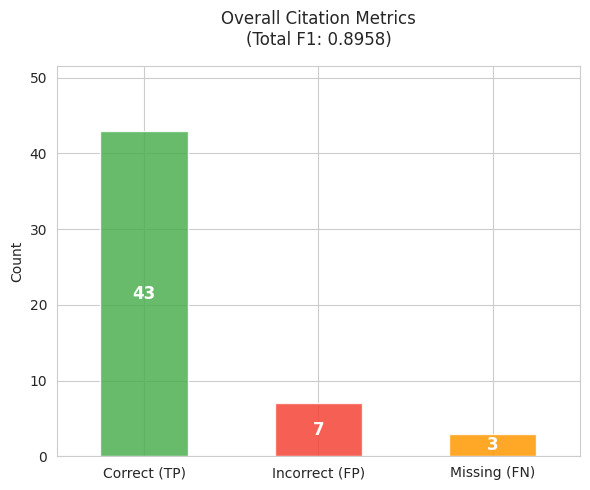

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def visualize_citation_performance(evaluation_dataset):
    """
    인용(Citation)의 TP, FP, FN 통계를 시각화
    """
    total_tp, total_fp, total_fn = 0, 0, 0

    # 1. 전역 F1 계산을 위한 데이터 분리
    ref_all = [item['reference_ref_list'] for item in evaluation_dataset]
    pred_all = [item['predicted_ref_list'] for item in evaluation_dataset]

    # 이전에 정의한 calculate_f1_score 호출
    overall_f1 = calculate_f1_score(ref_all, pred_all)

    # 2. 각 샘플별 통계 합산
    for ref, pred in zip(ref_all, pred_all):
        labels = set(ref)
        preds = set(pred)

        total_tp += len(labels.intersection(preds))
        total_fp += len(preds - labels)
        total_fn += len(labels - preds)

    # 3. 데이터 구성 및 시각화
    stats = pd.Series({
        'Correct (TP)': total_tp,
        'Incorrect (FP)': total_fp,
        'Missing (FN)': total_fn
    })

    plt.figure(figsize=(6, 5))
    # 바 크기를 조금 줄이고 내부 점수 시각화 개선
    ax = stats.plot(kind='bar', color=['#4CAF50', '#F44336', '#FF9800'], alpha=0.85)

    # f-string 내부의 복잡한 연산을 밖으로 빼서 에러 해결
    plt.title(f'Overall Citation Metrics\n(Total F1: {overall_f1:.4f})', pad=15)
    plt.ylabel('Count')
    plt.ylim(0, max(stats.values) * 1.2) # 상단 여유 공간 확보

    # 바 내부에 숫자 표시
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width()/2., height/2),
                    ha='center', va='center',
                    color='white', fontweight='bold', fontsize=12)

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 실행
visualize_citation_performance(evaluation_dataset)